In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

tf.keras.utils.set_random_seed(42)

In [2]:
olid_train = pd.read_csv("data/olid-train-small.csv")
olid_test = pd.read_csv("data/olid-test.csv")
hasoc_train = pd.read_csv("data/hasoc-train.csv")

print("OLID train:", olid_train.shape)
print("OLID test:", olid_test.shape)
print("HASOC train:", hasoc_train.shape)

OLID train: (5852, 3)
OLID test: (860, 3)
HASOC train: (5852, 3)


In [3]:
import os
import re
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from tensorflow.keras.callbacks import EarlyStopping

CNN_SEEDS = [0, 1, 2, 3, 4]
CNN_SETUPS = {
    "in_domain":    {"name": "In-domain: OLID → OLID",     "train": olid_train},
    "cross_domain": {"name": "Cross-domain: HASOC → OLID", "train": hasoc_train},
}
CNN_METRIC_COLS = [
    "NOT Precision", "NOT Recall", "NOT F1",
    "OFF Precision", "OFF Recall", "OFF F1",
    "Macro Precision", "Macro Recall", "Macro F1", "Accuracy",
]

os.makedirs("results", exist_ok=True)


def train_predict_cnn(train_df, test_df, seed):
    tf.keras.utils.set_random_seed(seed)

    # Shuffled, stratified dev split taken from the training data (never from the test set)
    train_part, dev_part = train_test_split(
        train_df, test_size=0.1, stratify=train_df["labels"], random_state=seed
    )

    # Texts as string tensors: recent Keras versions reject NumPy object arrays
    X_train = tf.constant(train_part["text"].astype(str).tolist())
    y_train = train_part["labels"].values
    X_dev = tf.constant(dev_part["text"].astype(str).tolist())
    y_dev = dev_part["labels"].values
    X_test = tf.constant(test_df["text"].astype(str).tolist())

    vectorizer = TextVectorization(
        max_tokens=20000,
        output_sequence_length=100
    )
    vectorizer.adapt(X_train)

    model = Sequential([
        vectorizer,
        Embedding(20000, 128),
        Conv1D(128, 5, activation="relu"),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_dev, y_dev),
        epochs=20,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    probabilities = model.predict(X_test, verbose=0).flatten()

    results = test_df.copy()
    results["probability"] = probabilities
    results["prediction"] = (probabilities >= 0.5).astype(int)
    results["seed"] = seed
    results["best_epoch"] = int(np.argmin(history.history["val_loss"])) + 1
    results["epochs_run"] = len(history.history["val_loss"])
    return results


def cnn_metrics(results, experiment_name):
    y_true = results["labels"]
    y_pred = results["prediction"]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    metrics = {
        "Experiment": experiment_name,
        "NOT Precision": precision[0],
        "NOT Recall": recall[0],
        "NOT F1": f1[0],
        "OFF Precision": precision[1],
        "OFF Recall": recall[1],
        "OFF F1": f1[1],
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Accuracy": accuracy_score(y_true, y_pred),
    }
    return metrics, confusion_matrix(y_true, y_pred, labels=[0, 1])

In [4]:
cnn_runs = {}  # (setup key, seed) -> predictions on the OLID test set

for key, setup in CNN_SETUPS.items():
    for seed in CNN_SEEDS:
        path = f"results/cnn_predictions_{key}_seed{seed}.csv"

        if os.path.exists(path):
            print(f"[{setup['name']} | seed {seed}] {path} already exists -> loading saved predictions")
            cnn_runs[key, seed] = pd.read_csv(path)
            continue

        print(f"[{setup['name']} | seed {seed}] training ...", end=" ")
        results = train_predict_cnn(setup["train"], olid_test, seed)
        results.to_csv(path, index=False)
        cnn_runs[key, seed] = results
        print(f"best epoch {results['best_epoch'].iloc[0]} "
              f"(stopped after {results['epochs_run'].iloc[0]}), saved to {path}")

[In-domain: OLID → OLID | seed 0] training ... best epoch 2 (stopped after 4), saved to results/cnn_predictions_in_domain_seed0.csv
[In-domain: OLID → OLID | seed 1] training ... best epoch 2 (stopped after 4), saved to results/cnn_predictions_in_domain_seed1.csv
[In-domain: OLID → OLID | seed 2] training ... best epoch 2 (stopped after 4), saved to results/cnn_predictions_in_domain_seed2.csv
[In-domain: OLID → OLID | seed 3] training ... best epoch 2 (stopped after 4), saved to results/cnn_predictions_in_domain_seed3.csv
[In-domain: OLID → OLID | seed 4] training ... best epoch 2 (stopped after 4), saved to results/cnn_predictions_in_domain_seed4.csv
[Cross-domain: HASOC → OLID | seed 0] training ... best epoch 2 (stopped after 4), saved to results/cnn_predictions_cross_domain_seed0.csv
[Cross-domain: HASOC → OLID | seed 1] training ... best epoch 2 (stopped after 4), saved to results/cnn_predictions_cross_domain_seed1.csv
[Cross-domain: HASOC → OLID | seed 2] training ... best epoch 

In [5]:
cnn_seed_rows = []
cnn_seed_cms = {key: [] for key in CNN_SETUPS}

for (key, seed), results in cnn_runs.items():
    metrics, cm = cnn_metrics(results, CNN_SETUPS[key]["name"])
    metrics["Seed"] = seed
    metrics["Best epoch"] = results["best_epoch"].iloc[0]
    cnn_seed_rows.append(metrics)
    cnn_seed_cms[key].append(cm)

cnn_seed_metrics = pd.DataFrame(cnn_seed_rows)

print("Per seed:")
display(cnn_seed_metrics.set_index(["Experiment", "Seed"]).round(4))

cnn_mean = cnn_seed_metrics.groupby("Experiment", sort=False)[CNN_METRIC_COLS].mean()
cnn_std = cnn_seed_metrics.groupby("Experiment", sort=False)[CNN_METRIC_COLS].std()

print(f"\nMean ± standard deviation over {len(CNN_SEEDS)} seeds:")
cnn_summary = cnn_mean.map(lambda v: f"{v:.4f}") + " ± " + cnn_std.map(lambda v: f"{v:.4f}")
display(cnn_summary.T)

# Cross-domain drop in macro F1
cnn_in_f1 = cnn_seed_metrics[cnn_seed_metrics["Experiment"] == CNN_SETUPS["in_domain"]["name"]].set_index("Seed")["Macro F1"]
cnn_cross_f1 = cnn_seed_metrics[cnn_seed_metrics["Experiment"] == CNN_SETUPS["cross_domain"]["name"]].set_index("Seed")["Macro F1"]
cnn_paired_drop = cnn_in_f1 - cnn_cross_f1

print(f"In-domain Macro F1:    {cnn_in_f1.mean():.4f} ± {cnn_in_f1.std():.4f}")
print(f"Cross-domain Macro F1: {cnn_cross_f1.mean():.4f} ± {cnn_cross_f1.std():.4f}")
print(f"Absolute drop:         {cnn_paired_drop.mean():.4f} ± {cnn_paired_drop.std():.4f} (paired by seed)")
print(f"Relative drop:         {cnn_paired_drop.mean() / cnn_in_f1.mean() * 100:.2f}%")
print(f"Seeds where cross-domain is lower: {(cnn_paired_drop > 0).sum()} of {len(cnn_paired_drop)}")

Per seed:


NOT Precision  NOT Recall  NOT F1  \
Experiment                 Seed                                      
In-domain: OLID → OLID     0            0.8271      0.9258  0.8737   
                           1            0.8239      0.9129  0.8661   
                           2            0.8402      0.8903  0.8645   
                           3            0.8457      0.9016  0.8728   
                           4            0.8435      0.8516  0.8475   
Cross-domain: HASOC → OLID 0            0.7831      0.7452  0.7636   
                           1            0.7561      0.8548  0.8024   
                           2            0.7686      0.5677  0.6531   
                           3            0.7845      0.5403  0.6399   
                           4            0.7919      0.5032  0.6154   

                                 OFF Precision  OFF Recall  OFF F1  \
Experiment                 Seed                                      
In-domain: OLID → OLID     0            0.7229      0.5000  0.5911   
                           1            0.6879      0.4958  0.5763   
                           2            0.6650      0.5625  0.6095   
                           3            0.6935      0.5750  0.6287   
                           4            0.6068      0.5917  0.5992   
Cross-domain: HASOC → OLID 0            0.4148      0.4667  0.4392   
                           1            0.4340      0.2875  0.3459   
                           2            0.3333      0.5583  0.4174   
                           3            0.3418      0.6167  0.4398   
                           4            0.3391      0.6583  0.4476   

                                 Macro Precision  Macro Recall  Macro F1  \
Experiment                 Seed                                            
In-domain: OLID → OLID     0              0.7750        0.7129    0.7324   
                           1              0.7559        0.7044    0.7212   
                           2              0.7526        0.7264    0.7370   
                           3              0.7696        0.7383    0.7507   
                           4              0.7251        0.7216    0.7233   
Cross-domain: HASOC → OLID 0              0.5989        0.6059    0.6014   
                           1              0.5950        0.5712    0.5741   
                           2              0.5509        0.5630    0.5353   
                           3              0.5632        0.5785    0.5399   
                           4              0.5655        0.5808    0.5315   

                                 Accuracy  Best epoch  
Experiment                 Seed                        
In-domain: OLID → OLID     0       0.8070           2  
                           1       0.7965           2  
                           2       0.7988           2  
                           3       0.8105           2  
                           4       0.7791           2  
Cross-domain: HASOC → OLID 0       0.6674           2  
                           1       0.6965           2  
                           2       0.5651           2  
                           3       0.5616           2  
                           4       0.5465           2


Mean ± standard deviation over 5 seeds:


Experiment,In-domain: OLID → OLID,Cross-domain: HASOC → OLID
NOT Precision,0.8361 ± 0.0099,0.7768 ± 0.0144
NOT Recall,0.8965 ± 0.0283,0.6423 ± 0.1509
NOT F1,0.8649 ± 0.0105,0.6949 ± 0.0827
OFF Precision,0.6752 ± 0.0434,0.3726 ± 0.0479
OFF Recall,0.5450 ± 0.0442,0.5175 ± 0.1473
OFF F1,0.6009 ± 0.0197,0.4180 ± 0.0419
Macro Precision,0.7556 ± 0.0194,0.5747 ± 0.0211
Macro Recall,0.7207 ± 0.0130,0.5799 ± 0.0161
Macro F1,0.7329 ± 0.0119,0.5564 ± 0.0303
Accuracy,0.7984 ± 0.0122,0.6074 ± 0.0692


In-domain Macro F1:    0.7329 ± 0.0119
Cross-domain Macro F1: 0.5564 ± 0.0303
Absolute drop:         0.1765 ± 0.0353 (paired by seed)
Relative drop:         24.08%
Seeds where cross-domain is lower: 5 of 5


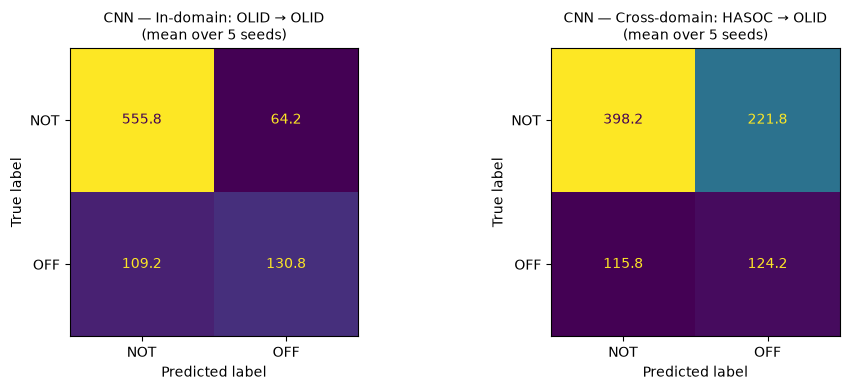

In [6]:
# Confusion matrices averaged over the seeds (mean number of tweets per cell)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (key, setup) in zip(axes, CNN_SETUPS.items()):
    mean_cm = np.mean(cnn_seed_cms[key], axis=0)
    ConfusionMatrixDisplay(
        confusion_matrix=mean_cm,
        display_labels=["NOT", "OFF"]
    ).plot(ax=ax, colorbar=False, values_format=".1f")
    ax.set_title(f"CNN — {setup['name']}\n(mean over {len(CNN_SEEDS)} seeds)", fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
# Same lowercasing and punctuation stripping as the default TextVectorization layer
CNN_PUNCT = re.compile(r"""[!"#$%&()\*\+,\-\./:;<=>?@\[\\\]^_`{|}~']""")


def cnn_tokens(text):
    return CNN_PUNCT.sub("", str(text).lower()).split()


cnn_datasets = {
    "OLID train (small)": olid_train,
    "HASOC train": hasoc_train,
    "OLID test": olid_test,
}
cnn_test_tokens = olid_test["text"].map(cnn_tokens)

cnn_stat_rows = []
for name, df in cnn_datasets.items():
    texts = df["text"].astype(str)
    tokens = texts.map(cnn_tokens)
    counts = Counter(token for tweet in tokens for token in tweet)
    vocab = {token for token, _ in counts.most_common(20000)}  # the model's vocabulary size

    row = {
        "Dataset": name,
        "Messages": len(df),
        "OFF share": df["labels"].mean(),
        "Mean tokens": tokens.map(len).mean(),
        "Median tokens": tokens.map(len).median(),
        "With @USER placeholder": texts.str.contains("@USER").mean(),
        "With real @handle": texts.str.contains(r"@(?!USER)\w").mean(),
        "With URL placeholder": texts.str.contains(r"\bURL\b").mean(),
        "With hashtag": texts.str.contains("#").mean(),
        "Vocabulary size": len(counts),
    }
    if name != "OLID test":
        test_token_list = [token for tweet in cnn_test_tokens for token in tweet]
        row["Test tokens unseen in this train set"] = np.mean([token not in vocab for token in test_token_list])
    cnn_stat_rows.append(row)

cnn_dataset_stats = pd.DataFrame(cnn_stat_rows).set_index("Dataset")
display(cnn_dataset_stats.T.round(3))

# Most frequent content words per dataset (stop words and the placeholders "user" / "url" removed)
print("\nMost frequent content words:")
for name, df in cnn_datasets.items():
    counts = Counter(
        token
        for tweet in df["text"].map(cnn_tokens)
        for token in tweet
        if token not in ENGLISH_STOP_WORDS and token not in {"user", "url"} and len(token) > 2
    )
    print(f"{name:20}", ", ".join(token for token, _ in counts.most_common(20)))

Dataset,OLID train (small),HASOC train,OLID test
Messages,5852.000,5852.000,860.000
OFF share,0.386,0.386,0.279
Mean tokens,22.325,23.061,24.151
Median tokens,18.000,21.000,22.000
With @USER placeholder,0.927,0.000,0.385
With real @handle,0.000,0.515,0.000
With URL placeholder,0.140,0.000,0.559
With hashtag,0.143,0.984,0.738
Vocabulary size,13730.000,18971.000,5503.000
Test tokens unseen in this train set,0.124,0.201,NaN



Most frequent content words:
OLID train (small)   gun, liberals, control, like, antifa, just, maga, conservatives, people, know, trump, amp, dont, think, good, right, shit, going, time, need
HASOC train          fucktrump, trumpisatraitor, icc, realdonaldtrump, doctorsfightback, trump, shameonicc, dhonikeepstheglove, doctors, amp, borisjohnsonshouldnotbepm, murderer, people, just, world, like, rapist, douchebag, resist, india
OLID test            liberals, conservatives, antifa, just, like, gun, control, maga, people, trump, dont, want, love, know, good, going, new, democrats, need, way


In [8]:
# Per tweet: mean prediction over seeds and number of seeds that got it wrong
cnn_errors = olid_test[["id", "text", "labels"]].copy()
cnn_errors["tokens"] = cnn_test_tokens.map(len)

for key, setup in CNN_SETUPS.items():
    predictions = np.column_stack([cnn_runs[key, seed]["prediction"].values for seed in CNN_SEEDS])
    cnn_errors[f"{key}_wrong"] = (predictions != cnn_errors["labels"].values[:, None]).sum(axis=1)

    train_vocab = {token for tweet in setup["train"]["text"].map(cnn_tokens) for token in tweet}
    cnn_errors[f"{key}_unseen"] = cnn_test_tokens.map(
        lambda tweet: np.mean([token not in train_vocab for token in tweet]) if tweet else 0.0
    )

n_seeds = len(CNN_SEEDS)
gold_off = cnn_errors["labels"] == 1

# 1. False positive / false negative rates (mean over seeds)
print("Error rates (mean over seeds):")
for key, setup in CNN_SETUPS.items():
    fp_rate = cnn_errors.loc[~gold_off, f"{key}_wrong"].sum() / (n_seeds * (~gold_off).sum())
    fn_rate = cnn_errors.loc[gold_off, f"{key}_wrong"].sum() / (n_seeds * gold_off.sum())
    always_wrong = (cnn_errors[f"{key}_wrong"] == n_seeds).sum()
    print(f"  {setup['name']:28} FP rate (gold NOT -> OFF): {fp_rate:.3f} | "
          f"FN rate (gold OFF -> NOT): {fn_rate:.3f} | wrong in all {n_seeds} seeds: {always_wrong} tweets")

in_always = cnn_errors["in_domain_wrong"] == n_seeds
cross_always = cnn_errors["cross_domain_wrong"] == n_seeds
in_never = cnn_errors["in_domain_wrong"] == 0
cross_never = cnn_errors["cross_domain_wrong"] == 0
print(f"\nWrong in all seeds in both setups: {(in_always & cross_always).sum()} tweets")
print(f"Always right in-domain, always wrong cross-domain: {(in_never & cross_always).sum()} tweets "
      f"(gold OFF: {(in_never & cross_always & gold_off).sum()})")
print(f"Always wrong in-domain, always right cross-domain: {(in_always & cross_never).sum()} tweets "
      f"(gold OFF: {(in_always & cross_never & gold_off).sum()})")

# 2. Error rate by tweet length (token-count tertiles of the test set)
cnn_errors["length bin"] = pd.qcut(cnn_errors["tokens"], 3, labels=["short", "medium", "long"])
length_table = pd.DataFrame({
    "tweets": cnn_errors.groupby("length bin", observed=True).size(),
    "token range": cnn_errors.groupby("length bin", observed=True)["tokens"].agg(lambda s: f"{s.min()}–{s.max()}"),
    **{
        f"error rate {setup['name']}": cnn_errors.groupby("length bin", observed=True)[f"{key}_wrong"].mean() / n_seeds
        for key, setup in CNN_SETUPS.items()
    },
})
print("\nError rate by tweet length:")
display(length_table.round(3))

# 3. Error rate by share of the tweet's tokens that never occur in the training set
unseen_bins = [-0.001, 0.0, 0.1, 0.25, 1.0]
unseen_labels = ["0%", "0–10%", "10–25%", ">25%"]
unseen_tables = []
for key, setup in CNN_SETUPS.items():
    bins = pd.cut(cnn_errors[f"{key}_unseen"], unseen_bins, labels=unseen_labels)
    unseen_tables.append(pd.DataFrame({
        (setup["name"], "tweets"): cnn_errors.groupby(bins, observed=False).size(),
        (setup["name"], "error rate"): cnn_errors.groupby(bins, observed=False)[f"{key}_wrong"].mean() / n_seeds,
    }))
print("Error rate by share of unseen tokens in the tweet:")
display(pd.concat(unseen_tables, axis=1).round(3))

Error rates (mean over seeds):
  In-domain: OLID → OLID       FP rate (gold NOT -> OFF): 0.104 | FN rate (gold OFF -> NOT): 0.455 | wrong in all 5 seeds: 90 tweets
  Cross-domain: HASOC → OLID   FP rate (gold NOT -> OFF): 0.358 | FN rate (gold OFF -> NOT): 0.482 | wrong in all 5 seeds: 109 tweets

Wrong in all seeds in both setups: 31 tweets
Always right in-domain, always wrong cross-domain: 43 tweets (gold OFF: 9)
Always wrong in-domain, always right cross-domain: 8 tweets (gold OFF: 5)

Error rate by tweet length:


,tweets,token range,error rate In-domain: OLID → OLID,error rate Cross-domain: HASOC → OLID
length bin,,,,
short,311,1–16,0.175,0.339
medium,271,17–30,0.229,0.434
long,278,31–62,0.205,0.412


Error rate by share of unseen tokens in the tweet:


In-domain: OLID → OLID            Cross-domain: HASOC → OLID           
                       tweets error rate                     tweets error rate
0%                        127      0.209                         13      0.262
0–10%                     272      0.222                        153      0.455
10–25%                    346      0.209                        386      0.410
>25%                      115      0.122                        308      0.345

In [9]:
def show_examples(mask, title, n=5):
    rows = cnn_errors[mask]
    print(f"\n{title}: {len(rows)} tweets, showing {min(n, len(rows))}")
    for _, row in rows.head(n).iterrows():
        gold = "OFF" if row["labels"] == 1 else "NOT"
        print(f"  [gold {gold}] {row['text'][:200]}")


for key, setup in CNN_SETUPS.items():
    always_wrong = cnn_errors[f"{key}_wrong"] == n_seeds
    show_examples(always_wrong & ~gold_off, f"{setup['name']}: false positives in all seeds")
    show_examples(always_wrong & gold_off, f"{setup['name']}: false negatives in all seeds")

show_examples(in_never & cross_always, "Always right in-domain but always wrong cross-domain")


In-domain: OLID → OLID: false positives in all seeds: 18 tweets, showing 5
  [gold NOT] Are you fucking serious?   URL
  [gold NOT] @USER @USER @USER I got in a pretty deep debate with my friend and she told me that latinos for Trump and blacks for Trump were paid supporters 😂 then I said you mean antifa are paid domestic terroris
  [gold NOT] #Florencehurricane 72 HOURS OF SUSTAINED LETHAL CYCLONIC FORCES, ONLY TO A FEW HOURS TO IMPACT TO  #NorthCarolina #SouthCarolina, AND #Georgia... DON'T BE STUPID... GET AWAY FROM THESE AREAS... @USER 
  [gold NOT] #WalkAway #DemocratSocialists #Socialists #Socialism #Resist #Communists #Antifa #Cult #Crazy #Insane #mentalillness #EmptyHeaded #BernieSanders #Venezuela 42 TRILLION in NEW TAXES #AlexandriaOcasioCo
  [gold NOT] @USER Exactly it’s bc slick woods has that unconventional look that she’s who she is yea she ain’t attractive to most of us but that shit don’t matter @ all lol

In-domain: OLID → OLID: false negatives in all seeds: 72 tweets